# Indian Pines: PCA vs Autoencoder

Hyperspectral imagery from the AVIRIS sensor — 145×145 pixels, 200 spectral bands, 16 land-cover classes. This is the **applied** half of the capstone: instead of asking how well each method *visualizes* the data (Notebook 1), we ask how well each method's compressed representation supports **downstream classification**.

**Sections:**
1. Setup & data loading
2. PCA — scree plot, 2D projection
3. Autoencoder — training, 2D projection (side-by-side with PCA)
4. Classification — accuracy + timing comparison, optional class map

## 1. Setup & Data Loading

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
import requests

import keras
keras.utils.set_random_seed(42)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

FIG_DIR = Path('figures/indian_pines')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str, fig=None) -> None:
    fig = fig or plt.gcf()
    for ext in ('pdf', 'png'):
        fig.savefig(FIG_DIR / f'{name}.{ext}')
    print(f'  saved -> {FIG_DIR}/{name}.{{pdf,png}}')

print('Setup complete.')

Setup complete.


In [2]:
# Download Indian Pines (.mat) files. First run downloads; subsequent runs skip.
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

FILES = {
    'Indian_pines_corrected.mat': 'https://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat',
    'Indian_pines_gt.mat':        'https://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat',
}

for fname, url in FILES.items():
    fpath = DATA_DIR / fname
    if fpath.exists() and fpath.stat().st_size > 1000:
        print(f'  {fname:35s} cached ({fpath.stat().st_size/1024:.0f} KB)')
        continue
    print(f'  downloading {fname}...')
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    with open(fpath, 'wb') as f:
        for chunk in r.iter_content(chunk_size=65536):
            f.write(chunk)
    print(f'    -> {fpath.stat().st_size/1024:.0f} KB')

img_cube = loadmat(DATA_DIR / 'Indian_pines_corrected.mat')['indian_pines_corrected']
gt_map = loadmat(DATA_DIR / 'Indian_pines_gt.mat')['indian_pines_gt']
print(f'\nImage cube : {img_cube.shape}   dtype={img_cube.dtype}')
print(f'Ground truth: {gt_map.shape}   dtype={gt_map.dtype}')

  Indian_pines_corrected.mat          cached (5814 KB)
  Indian_pines_gt.mat                 cached (1 KB)

Image cube : (145, 145, 200)   dtype=uint16
Ground truth: (145, 145)   dtype=uint8


In [3]:
# Standard Indian Pines class names (class 0 = unlabeled background)
CLASS_NAMES = [
    'Background',                     # 0
    'Alfalfa',                        # 1
    'Corn-notill',                    # 2
    'Corn-mintill',                   # 3
    'Corn',                           # 4
    'Grass-pasture',                  # 5
    'Grass-trees',                    # 6
    'Grass-pasture-mowed',            # 7
    'Hay-windrowed',                  # 8
    'Oats',                           # 9
    'Soybean-notill',                 # 10
    'Soybean-mintill',                # 11
    'Soybean-clean',                  # 12
    'Wheat',                          # 13
    'Woods',                          # 14
    'Buildings-Grass-Trees-Drives',   # 15
    'Stone-Steel-Towers',             # 16
]

# Flatten spatial dimensions: (145, 145, 200) -> (21025, 200)
H, W, B = img_cube.shape
X_all = img_cube.reshape(-1, B).astype(np.float32)
y_all = gt_map.reshape(-1)

# Drop unlabeled pixels (class 0)
labeled_mask = (y_all > 0)
X = X_all[labeled_mask]
y = y_all[labeled_mask]

# Standardize (zero-mean, unit-variance per band) — radiance values, not bounded
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f'After preprocessing:')
print(f'  X shape: {X.shape}    (n_pixels, n_bands)')
print(f'  y shape: {y.shape}    classes 1-16')
print(f'  X mean : {X.mean():+.3f},  X std: {X.std():.3f}    (post-standardization)')

print('\nClass distribution:')
for c, name in enumerate(CLASS_NAMES):
    if c == 0:
        continue
    n = (y == c).sum()
    bar = '#' * int(50 * n / 2500)
    print(f'  {c:2d}  {name:30s}  {n:5d}  {bar}')

After preprocessing:
  X shape: (10249, 200)    (n_pixels, n_bands)
  y shape: (10249,)    classes 1-16
  X mean : -0.000,  X std: 1.000    (post-standardization)

Class distribution:
   1  Alfalfa                            46  
   2  Corn-notill                      1428  ############################
   3  Corn-mintill                      830  ################
   4  Corn                              237  ####
   5  Grass-pasture                     483  #########
   6  Grass-trees                       730  ##############
   7  Grass-pasture-mowed                28  
   8  Hay-windrowed                     478  #########
   9  Oats                               20  
  10  Soybean-notill                    972  ###################
  11  Soybean-mintill                  2455  #################################################
  12  Soybean-clean                     593  ###########
  13  Wheat                             205  ####
  14  Woods                            1265  ##########

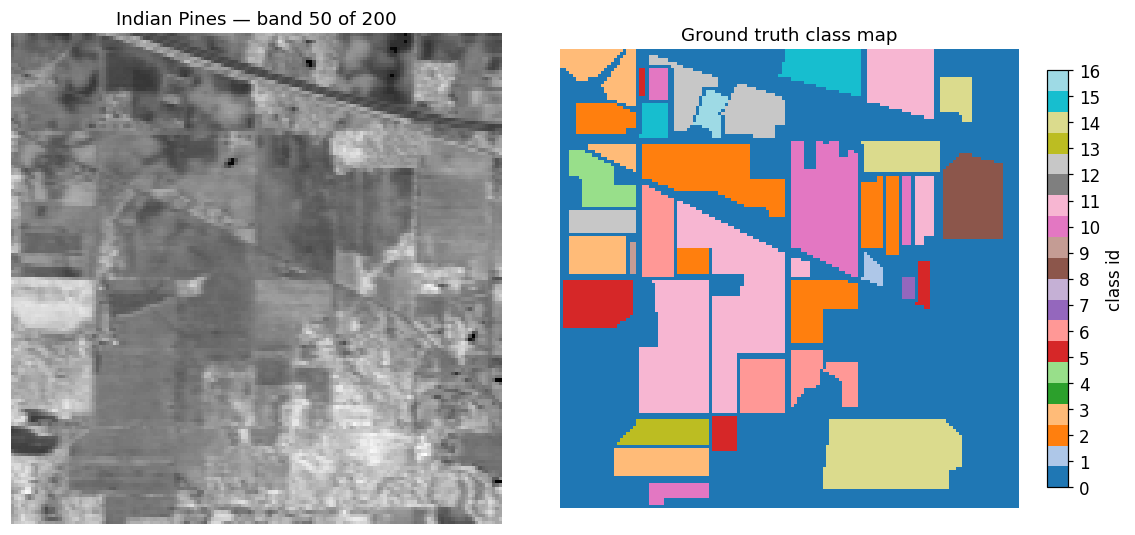

In [4]:
# Sanity check — show ground truth class map and a single band of the cube
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

ax1.imshow(img_cube[:, :, 50], cmap='gray')
ax1.set_title(f'Indian Pines — band 50 of {B}')
ax1.axis('off')

im = ax2.imshow(gt_map, cmap='tab20', vmin=0, vmax=16)
ax2.set_title('Ground truth class map')
ax2.axis('off')
fig.colorbar(im, ax=ax2, ticks=range(0, 17), shrink=0.85, label='class id')

plt.tight_layout()
plt.show()

## 2. PCA — Scree Plot, 2D Projection

Hyperspectral data is famously redundant: neighbouring bands are highly correlated, so a small number of PCs typically captures the great majority of variance. We expect the scree plot to be much steeper than MNIST's.

In [5]:
from sklearn.decomposition import PCA

print('Fitting PCA on all 200 spectral bands...')
t0 = time.time()
pca_full = PCA(n_components=200, random_state=42).fit(X)
pca_time = time.time() - t0
print(f'  done in {pca_time:.3f}s')

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
k_90 = int(np.searchsorted(cum_var, 0.90)) + 1
k_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f'  components for 90% variance: {k_90}')
print(f'  components for 95% variance: {k_95}')
print(f'  variance captured by first 15 components: {cum_var[14]*100:.2f}%')

Fitting PCA on all 200 spectral bands...
  done in 0.019s
  components for 90% variance: 3
  components for 95% variance: 9
  variance captured by first 15 components: 96.86%


### Figure 1 — Scree plot (variance explained)

  saved -> figures\indian_pines/fig1_scree.{pdf,png}


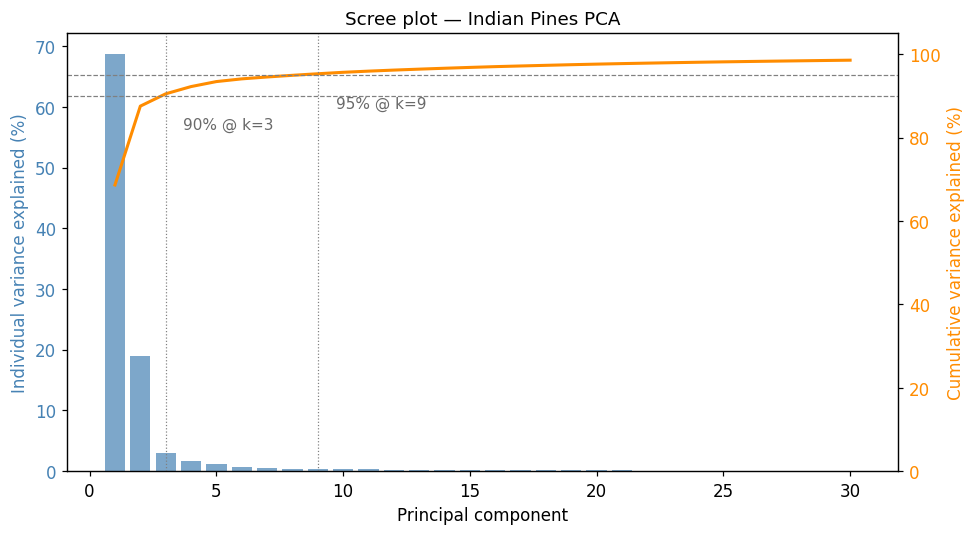

In [6]:
n_show = max(30, k_95 + 5)
x_axis = np.arange(1, n_show + 1)
indiv = pca_full.explained_variance_ratio_[:n_show] * 100
cum = cum_var[:n_show] * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(x_axis, indiv, color='steelblue', alpha=0.7, label='Individual variance')
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Individual variance explained (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(x_axis, cum, color='darkorange', linewidth=2, label='Cumulative variance')
ax2.set_ylabel('Cumulative variance explained (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 105)

for thresh, k in [(90, k_90), (95, k_95)]:
    ax2.axhline(thresh, color='gray', linestyle='--', linewidth=0.8)
    ax2.axvline(k, color='gray', linestyle=':', linewidth=0.8)
    ax2.annotate(f'{thresh}% @ k={k}', xy=(k, thresh),
                 xytext=(k + 0.7, thresh - 8), fontsize=10, color='dimgray')

ax1.set_title('Scree plot — Indian Pines PCA')
plt.tight_layout()
save_fig('fig1_scree')
plt.show()

### Figure 2 — PCA 2D projection (PC1 vs PC2)

Each pixel becomes one point, colored by its land-cover class. Tight clusters = the first two PCs preserve the spectral signature of that class; overlapping classes will likely need more components (or a nonlinear method) to be separated.

  saved -> figures\indian_pines/fig2_pca_2d_projection.{pdf,png}


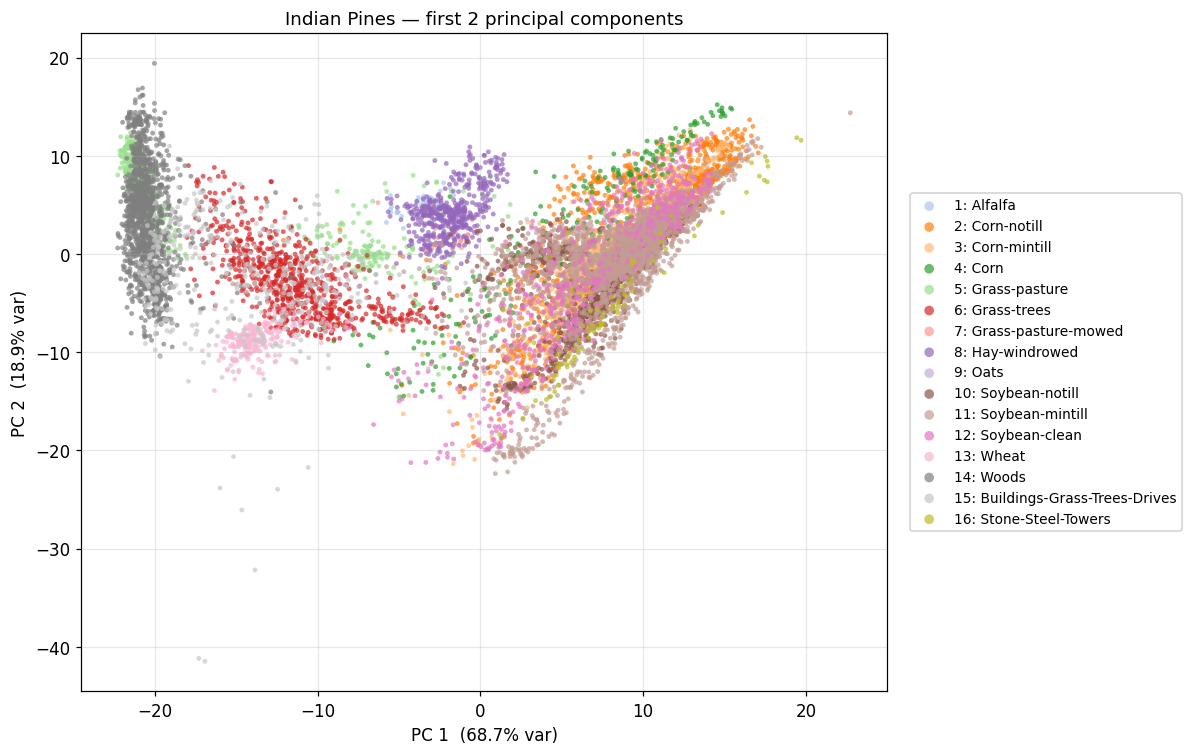

In [8]:
pca_2d_proj = pca_full.transform(X)[:, :2]

# Use tab20 — 16 distinguishable colors. Skip color 0 (used for background in the GT map).
n_classes = 16
cmap = plt.cm.tab20
class_colors = [cmap(i % 20) for i in range(1, n_classes + 1)]

fig, ax = plt.subplots(figsize=(11, 7))
for c in range(1, n_classes + 1):
    mask = (y == c)
    ax.scatter(pca_2d_proj[mask, 0], pca_2d_proj[mask, 1],
               c=[class_colors[c - 1]], s=10, alpha=0.7,
               edgecolors='none', label=f'{c}: {CLASS_NAMES[c]}')

ax.set_xlabel(f'PC 1  ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC 2  ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Indian Pines — first 2 principal components')
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          markerscale=2, framealpha=0.9, fontsize=9)
plt.tight_layout()
save_fig('fig2_pca_2d_projection')
plt.show()

## 3. Autoencoder — Train, 2D Projection vs PCA

**Architecture:** 200 → 128 → 64 → latent_dim → 64 → 128 → 200, ReLU activations, **linear output** (the data is standardized — values are negative — so sigmoid would clip them).

We train two autoencoders:
- `ae_15` with **latent_dim=15** — matches PCA's 15 components for the classification comparison in Section 4.
- `ae_2` with **latent_dim=2**  — for side-by-side visualization with the PCA 2D scatter.

In [9]:
from keras import layers, Model, Input

LATENT_DIM = 15  # matches PCA components for the classification comparison

def build_autoencoder(latent_dim: int):
    inp = Input(shape=(200,), name='input')
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dense(64, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu', name='latent')(x)

    x = layers.Dense(64, activation='relu')(z)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(200, activation='linear', name='output')(x)

    autoencoder = Model(inp, out, name=f'autoencoder_d{latent_dim}')
    encoder = Model(inp, z, name=f'encoder_d{latent_dim}')
    return autoencoder, encoder

ae_15, encoder_15 = build_autoencoder(LATENT_DIM)
ae_15.compile(optimizer='adam', loss='mse')
ae_15.summary()

Model: "autoencoder_d15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 15)             │           975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,103 (273.84 KB)

 Trainable params: 70,103 (273.84 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
print(f'Training autoencoder at latent_dim={LATENT_DIM}...')
t0 = time.time()
hist_15 = ae_15.fit(
    X, X,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    verbose=2,
)
ae_15_train_time = time.time() - t0
print()
print(f'Done in {ae_15_train_time:.1f}s')
print(f'Final train MSE: {hist_15.history["loss"][-1]:.4f}')
print(f'Final val   MSE: {hist_15.history["val_loss"][-1]:.4f}')

Training autoencoder at latent_dim=15...
Epoch 1/100
145/145 - 3s - 19ms/step - loss: 0.2111 - val_loss: 0.0808
Epoch 2/100
145/145 - 0s - 3ms/step - loss: 0.0678 - val_loss: 0.0643
Epoch 3/100
145/145 - 0s - 3ms/step - loss: 0.0550 - val_loss: 0.0581
Epoch 4/100
145/145 - 0s - 3ms/step - loss: 0.0499 - val_loss: 0.0533
Epoch 5/100
145/145 - 0s - 3ms/step - loss: 0.0462 - val_loss: 0.0498
Epoch 6/100
145/145 - 0s - 3ms/step - loss: 0.0427 - val_loss: 0.0469
Epoch 7/100
145/145 - 0s - 3ms/step - loss: 0.0399 - val_loss: 0.0451
Epoch 8/100
145/145 - 1s - 5ms/step - loss: 0.0378 - val_loss: 0.0423
Epoch 9/100
145/145 - 0s - 3ms/step - loss: 0.0361 - val_loss: 0.0404
Epoch 10/100
145/145 - 0s - 3ms/step - loss: 0.0345 - val_loss: 0.0399
Epoch 11/100
145/145 - 0s - 3ms/step - loss: 0.0334 - val_loss: 0.0406
Epoch 12/100
145/145 - 0s - 3ms/step - loss: 0.0324 - val_loss: 0.0395
Epoch 13/100
145/145 - 1s - 4ms/step - loss: 0.0314 - val_loss: 0.0385
Epoch 14/100
145/145 - 0s - 3ms/step - loss:

### Training curve

  saved -> figures\indian_pines/fig_ae_training_curve.{pdf,png}


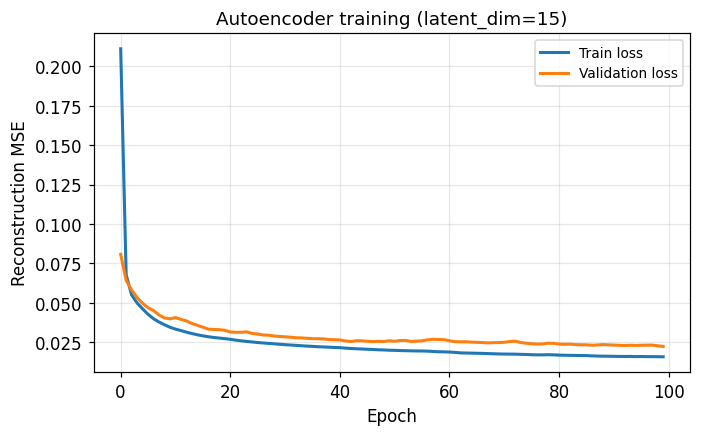

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_15.history['loss'], label='Train loss', linewidth=2)
ax.plot(hist_15.history['val_loss'], label='Validation loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction MSE')
ax.set_title(f'Autoencoder training (latent_dim={LATENT_DIM})')
ax.legend()
ax.grid(alpha=0.3)
save_fig('fig_ae_training_curve')
plt.show()

### Train a separate autoencoder with latent_dim=2 (for visualization)

In [12]:
ae_2, encoder_2 = build_autoencoder(latent_dim=2)
ae_2.compile(optimizer='adam', loss='mse')

print('Training 2D-bottleneck autoencoder...')
t0 = time.time()
hist_2 = ae_2.fit(
    X, X,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    verbose=2,
)
ae_2_train_time = time.time() - t0
print()
print(f'Done in {ae_2_train_time:.1f}s. Final val MSE: {hist_2.history["val_loss"][-1]:.4f}')

Training 2D-bottleneck autoencoder...
Epoch 1/100
145/145 - 2s - 16ms/step - loss: 0.4580 - val_loss: 0.1200
Epoch 2/100
145/145 - 0s - 3ms/step - loss: 0.1268 - val_loss: 0.1049
Epoch 3/100
145/145 - 0s - 3ms/step - loss: 0.1035 - val_loss: 0.0846
Epoch 4/100
145/145 - 0s - 3ms/step - loss: 0.0946 - val_loss: 0.0793
Epoch 5/100
145/145 - 0s - 3ms/step - loss: 0.0901 - val_loss: 0.0767
Epoch 6/100
145/145 - 1s - 4ms/step - loss: 0.0874 - val_loss: 0.0746
Epoch 7/100
145/145 - 1s - 4ms/step - loss: 0.0857 - val_loss: 0.0729
Epoch 8/100
145/145 - 1s - 4ms/step - loss: 0.0835 - val_loss: 0.0711
Epoch 9/100
145/145 - 1s - 4ms/step - loss: 0.0815 - val_loss: 0.0700
Epoch 10/100
145/145 - 0s - 3ms/step - loss: 0.0800 - val_loss: 0.0690
Epoch 11/100
145/145 - 0s - 3ms/step - loss: 0.0783 - val_loss: 0.0684
Epoch 12/100
145/145 - 0s - 3ms/step - loss: 0.0764 - val_loss: 0.0673
Epoch 13/100
145/145 - 0s - 3ms/step - loss: 0.0738 - val_loss: 0.0676
Epoch 14/100
145/145 - 1s - 3ms/step - loss: 0.

### Figure 3 — 2D projections side-by-side

PCA's first two components vs the autoencoder's 2D bottleneck. The question for the paper: does the nonlinear method achieve cleaner class separation in only 2 dimensions?

  saved -> figures\indian_pines/fig3_2d_projections.{pdf,png}


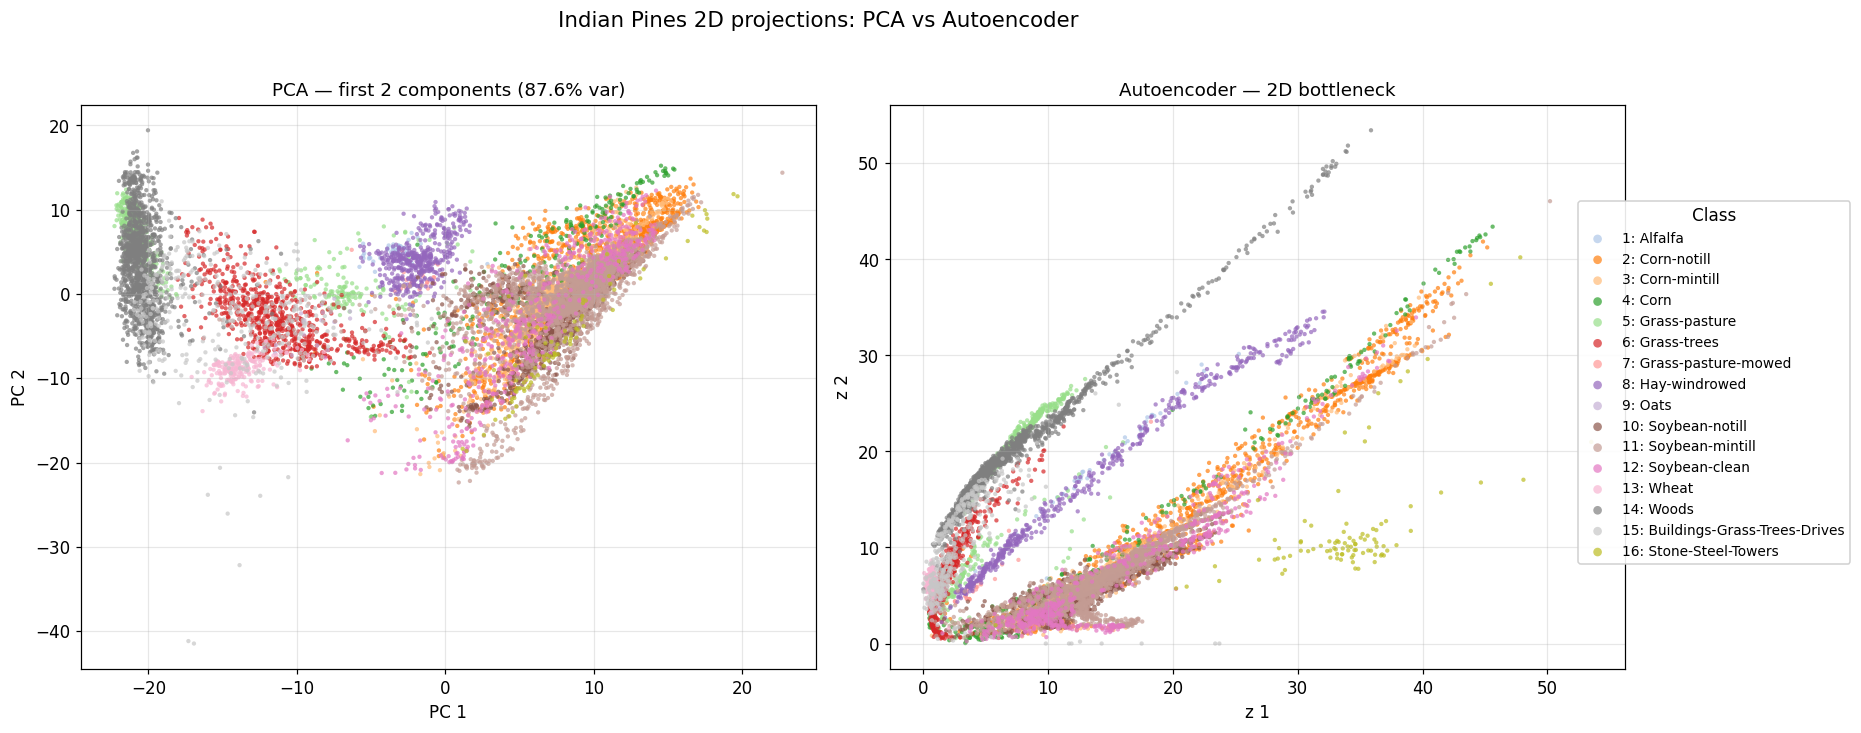

In [13]:
ae_2d_proj = encoder_2.predict(X, verbose=0)

fig, (ax_pca, ax_ae) = plt.subplots(1, 2, figsize=(15, 6.5))

for c in range(1, n_classes + 1):
    mask = (y == c)
    color = [class_colors[c - 1]]
    label = f'{c}: {CLASS_NAMES[c]}'
    ax_pca.scatter(pca_2d_proj[mask, 0], pca_2d_proj[mask, 1],
                   c=color, s=8, alpha=0.7, edgecolors='none', label=label)
    ax_ae.scatter(ae_2d_proj[mask, 0], ae_2d_proj[mask, 1],
                  c=color, s=8, alpha=0.7, edgecolors='none', label=label)

ax_pca.set_title(f'PCA — first 2 components ({(pca_full.explained_variance_ratio_[:2].sum()*100):.1f}% var)')
ax_pca.set_xlabel('PC 1')
ax_pca.set_ylabel('PC 2')

ax_ae.set_title('Autoencoder — 2D bottleneck')
ax_ae.set_xlabel('z 1')
ax_ae.set_ylabel('z 2')

for ax in (ax_pca, ax_ae):
    ax.grid(alpha=0.3)

# Single shared legend on the right of the figure
handles, labels = ax_ae.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.13, 0.5),
           markerscale=2, framealpha=0.9, fontsize=9, title='Class')

fig.suptitle('Indian Pines 2D projections: PCA vs Autoencoder', fontsize=14, y=1.02)
plt.tight_layout()
save_fig('fig3_2d_projections')
plt.show()

## 4. Classification Comparison

The 2D plots are pretty but the *real* test is downstream utility: if we reduce dimensionality with each method and feed the result into the same classifier, which preserves more class-discriminative information?

**Protocol:**
1. Stratified 70/30 train/test split.
2. Reduce both train and test sets to **15 dims** with PCA, then again with the autoencoder's encoder (using the already-trained `ae_15`).
3. Train two classifiers on each reduced dataset: **Random Forest** and **MLP**.
4. Compare test accuracy and dimensionality-reduction time.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print(f'Train classes: {len(np.unique(y_train))}   Test classes: {len(np.unique(y_test))}')

Train: (7174, 200)   Test: (3075, 200)
Train classes: 16   Test classes: 16


### Reduce dimensionality with both methods (to 15 dims)

In [15]:
# PCA — fit on training data only (avoids leakage)
print('Reducing with PCA...')
t0 = time.time()
pca_dr = PCA(n_components=LATENT_DIM, random_state=42).fit(X_train)
X_train_pca = pca_dr.transform(X_train)
X_test_pca = pca_dr.transform(X_test)
pca_dr_time = time.time() - t0
print(f'  fit + transform: {pca_dr_time:.3f}s')
print(f'  variance captured: {pca_dr.explained_variance_ratio_.sum()*100:.2f}%')

# Autoencoder — already trained on full X. Just transform.
print('Reducing with autoencoder...')
t0 = time.time()
X_train_ae = encoder_15.predict(X_train, verbose=0)
X_test_ae = encoder_15.predict(X_test, verbose=0)
ae_dr_time = time.time() - t0
print(f'  encode-only time: {ae_dr_time:.3f}s   (training took {ae_15_train_time:.1f}s separately)')
print()
print(f'Reduced shapes:  PCA {X_train_pca.shape}    AE {X_train_ae.shape}')

Reducing with PCA...
  fit + transform: 0.028s
  variance captured: 96.85%
Reducing with autoencoder...
  encode-only time: 0.970s   (training took 45.8s separately)

Reduced shapes:  PCA (7174, 15)    AE (7174, 15)


### Train two classifiers on each reduced representation

In [16]:
results = []

for dr_name, X_tr, X_te in [('PCA', X_train_pca, X_test_pca),
                            ('AE',  X_train_ae,  X_test_ae)]:
    for clf_name, clf in [
        ('RandomForest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ('MLP',          MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)),
    ]:
        t0 = time.time()
        clf.fit(X_tr, y_train)
        train_t = time.time() - t0
        acc = accuracy_score(y_test, clf.predict(X_te))
        results.append({
            'DR': dr_name,
            'Classifier': clf_name,
            'Accuracy (%)': acc * 100,
            'DR Time (s)':  pca_dr_time if dr_name == 'PCA' else ae_dr_time,
            'Clf Train (s)': train_t,
        })
        print(f'  {dr_name:3s} + {clf_name:13s}  acc = {acc*100:5.2f}%   clf train = {train_t:.2f}s')

results_df = pd.DataFrame(results)
print()
print('=' * 72)
print(f'SUMMARY  (n_train={len(X_train)}, n_test={len(X_test)}, latent_dim={LATENT_DIM})')
print('=' * 72)
print(results_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
results_df.to_csv(FIG_DIR / 'summary_table.csv', index=False)
print(f'  saved -> {FIG_DIR}/summary_table.csv')

  PCA + RandomForest   acc = 79.93%   clf train = 1.21s


c:\Users\berez\Documents\github\PCA\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  PCA + MLP            acc = 82.96%   clf train = 8.57s
  AE  + RandomForest   acc = 75.61%   clf train = 0.94s
  AE  + MLP            acc = 80.55%   clf train = 8.51s

SUMMARY  (n_train=7174, n_test=3075, latent_dim=15)
 DR   Classifier  Accuracy (%)  DR Time (s)  Clf Train (s)
PCA RandomForest        79.935        0.028          1.209
PCA          MLP        82.959        0.028          8.568
 AE RandomForest        75.610        0.970          0.943
 AE          MLP        80.553        0.970          8.512
  saved -> figures\indian_pines/summary_table.csv


c:\Users\berez\Documents\github\PCA\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


### Figure 4 — Classification accuracy (PCA vs AE) for each classifier

  saved -> figures\indian_pines/fig4_classification_accuracy.{pdf,png}


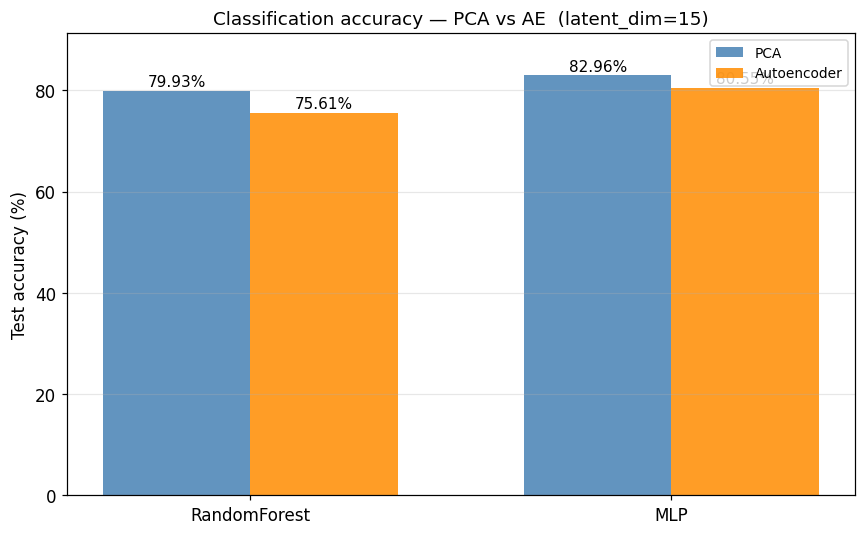

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

classifiers = ['RandomForest', 'MLP']
x = np.arange(len(classifiers))
width = 0.35

pca_accs = [results_df.query('DR == "PCA" and Classifier == @c')['Accuracy (%)'].iloc[0] for c in classifiers]
ae_accs  = [results_df.query('DR == "AE"  and Classifier == @c')['Accuracy (%)'].iloc[0] for c in classifiers]

bars1 = ax.bar(x - width/2, pca_accs, width, color='steelblue', label='PCA', alpha=0.85)
bars2 = ax.bar(x + width/2, ae_accs,  width, color='darkorange', label='Autoencoder', alpha=0.85)

for bars, accs in [(bars1, pca_accs), (bars2, ae_accs)]:
    for b, v in zip(bars, accs):
        ax.text(b.get_x() + b.get_width()/2, v + 0.3, f'{v:.2f}%',
                ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(classifiers)
ax.set_ylabel('Test accuracy (%)')
ax.set_title(f'Classification accuracy — PCA vs AE  (latent_dim={LATENT_DIM})')
ax.set_ylim(0, max(max(pca_accs), max(ae_accs)) * 1.10)
ax.grid(alpha=0.3, axis='y')
ax.legend()
plt.tight_layout()
save_fig('fig4_classification_accuracy')
plt.show()

### Figure 5 — Timing comparison

Total time = dimensionality-reduction fitting + classifier training. For the AE we count its full training time, since that's what's actually required to reproduce the result.

  saved -> figures\indian_pines/fig5_timing.{pdf,png}


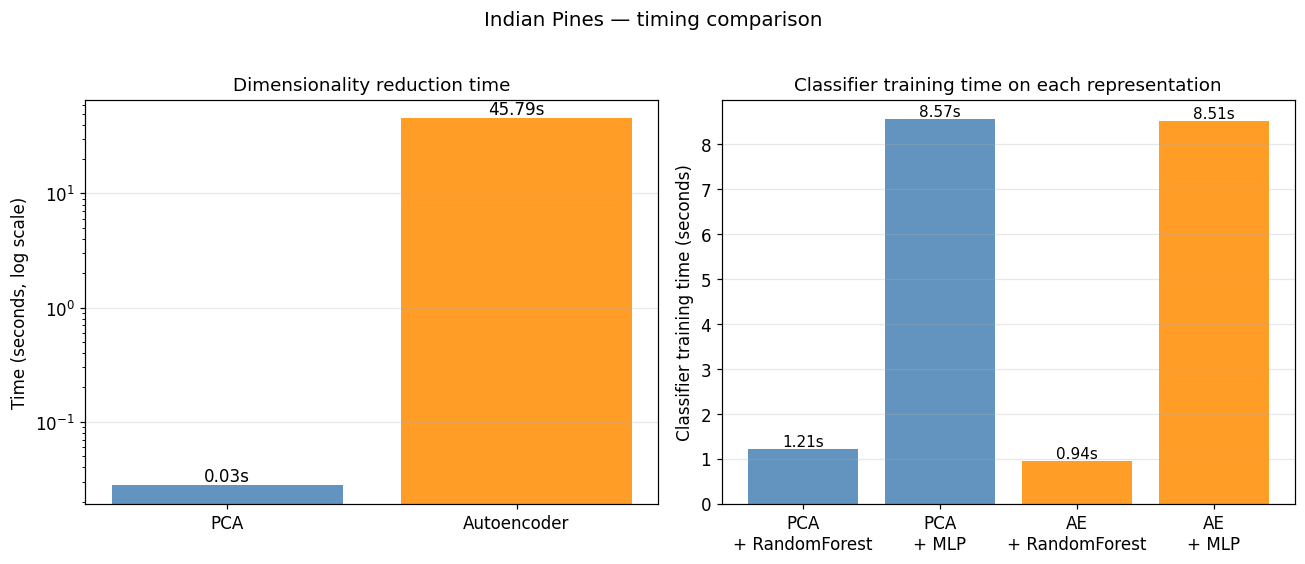

In [18]:
fig, (ax_dr, ax_total) = plt.subplots(1, 2, figsize=(12, 5))

# Left: just the dimensionality-reduction step (note: AE includes full training)
methods = ['PCA', 'Autoencoder']
dr_times = [pca_dr_time, ae_15_train_time]
colors = ['steelblue', 'darkorange']

bars = ax_dr.bar(methods, dr_times, color=colors, alpha=0.85)
ax_dr.set_ylabel('Time (seconds, log scale)')
ax_dr.set_yscale('log')
ax_dr.set_title('Dimensionality reduction time')
for b, v in zip(bars, dr_times):
    ax_dr.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}s',
               ha='center', va='bottom', fontsize=11)
ax_dr.grid(alpha=0.3, axis='y')

# Right: classifier training time on each representation
labels = [f"{r['DR']}\n+ {r['Classifier']}" for r in results]
clf_times = [r['Clf Train (s)'] for r in results]
bar_colors = ['steelblue' if r['DR'] == 'PCA' else 'darkorange' for r in results]
bars2 = ax_total.bar(labels, clf_times, color=bar_colors, alpha=0.85)
for b, v in zip(bars2, clf_times):
    ax_total.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}s',
                  ha='center', va='bottom', fontsize=10)
ax_total.set_ylabel('Classifier training time (seconds)')
ax_total.set_title('Classifier training time on each representation')
ax_total.grid(alpha=0.3, axis='y')

fig.suptitle('Indian Pines — timing comparison', y=1.02, fontsize=13)
plt.tight_layout()
save_fig('fig5_timing')
plt.show()

### Figure 6 (optional) — Classification map

Apply each trained classifier to **every pixel** in the 145×145 image (not just the labeled ones), then visualize the predicted class. Shows how each method generalizes the spectral patterns to the full scene.

In [19]:
# Standardize the FULL image cube using the same scaler
X_all_std = scaler.transform(X_all)

# Reduce all pixels with both methods
X_all_pca = pca_dr.transform(X_all_std)
X_all_ae  = encoder_15.predict(X_all_std, verbose=0)

# Use Random Forest classifiers — typically the strongest baseline on small tabular data
rf_pca = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train_pca, y_train)
rf_ae  = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train_ae,  y_train)

pred_pca = rf_pca.predict(X_all_pca).reshape(H, W)
pred_ae  = rf_ae.predict(X_all_ae).reshape(H, W)

  saved -> figures\indian_pines/fig6_classification_maps.{pdf,png}


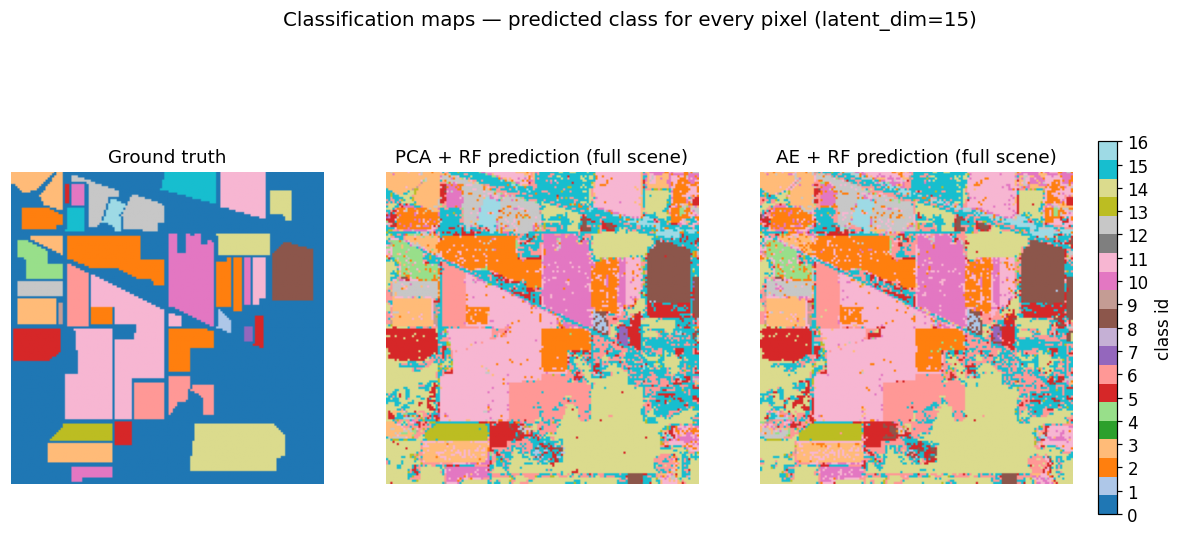

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

axes[0].imshow(gt_map, cmap='tab20', vmin=0, vmax=16)
axes[0].set_title('Ground truth')
axes[0].axis('off')

axes[1].imshow(pred_pca, cmap='tab20', vmin=0, vmax=16)
axes[1].set_title('PCA + RF prediction (full scene)')
axes[1].axis('off')

im = axes[2].imshow(pred_ae, cmap='tab20', vmin=0, vmax=16)
axes[2].set_title('AE + RF prediction (full scene)')
axes[2].axis('off')

fig.colorbar(im, ax=axes, ticks=range(0, 17), shrink=0.8, label='class id', pad=0.02)
fig.suptitle('Classification maps — predicted class for every pixel (latent_dim=15)', y=1.02, fontsize=13)
save_fig('fig6_classification_maps')
plt.show()